# Theory:
* Making a Regressoin Tree, by checking division between every data point and finding RMSE between avg value of left and right node and actual values, then choosing the split with least RMSE and thus forming a division.
* This is done recursively

### Base condition for Recusion:
* If leaf nodes are pure, no more division is possible.
* Other stopping criterion are met (e.g. max depth).

##### Implementing: [Video](https://www.youtube.com/watch?v=g9c66TUylZ4&list=PLN9DbzNoozxbIClspO-CCaBPkem6SWBnH)

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

In [2]:
# Load the data
train = pd.read_csv('../data/leaf-classification/train.csv')
test = pd.read_csv('../data/leaf-classification/test.csv')
X = train.drop(columns=['species', 'id', 'margin1']).values
y = train['margin1'].values

# Train-Validation Split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=123)

X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((792, 191), (198, 191), (792,), (198,))

### Analyzing the same thing using XGBoost:

In [3]:
from xgboost import XGBRegressor as m
from sklearn.metrics import mean_squared_error
model = m(random_state=123)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
rmse = np.sqrt(np.mean(np.square(y_valid- y_pred)))
(f"RMSE: {rmse}")

'RMSE: 0.008020571776182688'

In [4]:
np.sqrt(np.mean(np.square(y - np.mean(y)))) # Average would have given 0.019 std, while we are getting 0.008 RMSE

np.float64(0.019729031619523132)

### Building Regression Tree

In [5]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):
        # A Node can either be a Decision Node or a Pure Node
        
        # Decision Node
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right

        # Leaf Node
        self.value = value

In [6]:
class RegressionTree:
    def __init__(self, min_samples_split=2, max_depth=2):
        # Min Samples for splitting to occur
        self.min_samples_split=min_samples_split
        # Max depth for base case and preventing overfitting
        self.max_depth = max_depth

    def build_tree(self, X, y, curr_depth=0):
        n_samples, n_features = X.shape

        # Must not be base condition 
        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.best_split(X, y)

            # Check if valid split was found
            if best_split["feature_idx"] is not None:
                left_node = self.build_tree(best_split["left_X"], best_split["left_y"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_X"], best_split["right_y"], curr_depth + 1)
    
                return Node(best_split["feature_idx"], best_split["threshold"], best_split["loss"], left_node, right_node)

        # Returning a Pure Node with AVG value
        return Node(value=np.mean(y))

    # Can be Vectorized as well
    def predict(self, X):
        predictions = [self.predict_value(row, self.root) for row in X]
        return predictions

    def predict_value(self, x, node):
        # Leaf Node: Base case
        if node.value is not None:
            return node.value
        # Decision Node
        feature_value = x[node.feature_idx] 
        if feature_value <= node.threshold:
            return self.predict_value(x, node.left)
        else:
            return self.predict_value(x, node.right)

    def fit(self, X, y):
        self.root = self.build_tree(X, y)

In greater detail, for any $j$ and $s$, we define the pair of half-planes
$$R_1(j, s) = \{X|X_j < s\}\ and\ R_2(j, s) = \{X|X_j ≥ s\},\ \ \ \ (8.2)$$
and we seek the value of $j$ and $s$ that minimize the equation
$$\sum_{i: x_i \in R_1(j, s)}(y_i−\hat{y}_{R_1})^2 + \sum_{i: x_i \in R_2(j, s)}(y_i−\hat{y}_{R_2})^2,\ \ \ (8.3)$$

where $\hat{y}_{R_1}$ is the mean response for the training observations in $R_1(j, s)$, and $\hat{y}{R_2}$ is the mean response for the training observations in $R_2(j, s)$.
Finding the values of $j$ and $s$ that minimize $(8.3)$ can be done quite quickly, especially when the number of features p is not too large.
I  did so  using brute force.

In [7]:
def best_split(self, X, y):
    b_split = {
        "feature_idx": None,
        "threshold": None,
        "loss": float('inf'),
        "left_X": None,
        "left_y": None,
        "right_X": None,
        "right_y": None
    }

    n_feature = X.shape[-1]

    # Trying every possible feature x with every possible threshold to break and find resulting purity
    for feature_idx in range(n_feature):
        feature_values = X[:, feature_idx]
        thresholds = np.unique(feature_values)

        for threshold in thresholds:
            mask = X[:, feature_idx] <=threshold
            left_X = X[mask]
            left_y = y[mask]
            right_X = X[~mask]
            right_y = y[~mask]

            if len(left_y) and len(right_y):
                loss = np.sum(np.square(left_y - np.mean(left_y))) + np.sum(np.square(right_y - np.mean(right_y))) 

                if loss < b_split["loss"]:
                    b_split["feature_idx"] = feature_idx
                    b_split["threshold"] = threshold
                    b_split["loss"] = loss
                    b_split["left_X"] = left_X
                    b_split["left_y"] = left_y
                    b_split["right_X"] = right_X
                    b_split["right_y"] = right_y

    return b_split

RegressionTree.best_split = best_split

In [8]:
def best_split(self, X, y):
    b_split = {
        "feature_idx": None,
        "threshold": None,
        "loss": float('inf'),
        "left_X": None,
        "left_y": None,
        "right_X": None,
        "right_y": None
    }

    y_reshaped = y.reshape(-1, 1)

    for feature_idx in range(X.shape[-1]):

        # Making all masks of feature_idx over all possible thresholds
        thresholds = np.unique(X[:, feature_idx], axis=0)                   # (thresholds,)
        left_mask = X[:, feature_idx].reshape(-1, 1) <= thresholds          # (rows, 1) <= (thresholds) = (rows, thresholds)
        right_mask = ~left_mask

        # Need to find the Sum Squared Error
        left_counts = np.sum(left_mask, axis=0)                             # (rows, thresholds).sum(axis=0) = (thresholds)
        right_counts = np.sum(right_mask, axis=0)

        valid_splits = (left_counts > 0) & (right_counts >0)

        if not np.any(valid_splits):
            continue

        left_sums = np.sum(left_mask * y_reshaped, axis=0)
        right_sums = np.sum(right_mask * y_reshaped, axis=0)

        left_means = np.divide(left_sums, left_counts, out=np.zeros_like(left_sums, dtype=float), where=left_counts!=0)
        right_means = np.divide(right_sums, right_counts, out=np.zeros_like(right_sums, dtype=float), where=right_counts!=0)

        left_sse = np.sum(np.square(y_reshaped - left_means) * left_mask, axis=0)
        right_sse = np.sum(np.square(y_reshaped - right_means) * right_mask, axis=0)

        loss = left_sse + right_sse

        loss[~valid_splits] = float('inf')
        best_thresh_idx = np.argmin(loss)

        if loss[best_thresh_idx] < b_split["loss"] and loss[best_thresh_idx] != float('inf'):
            winning_mask = left_mask[:, best_thresh_idx]
            b_split["feature_idx"] = feature_idx
            b_split["threshold"] = thresholds[best_thresh_idx]
            b_split["loss"] = loss[best_thresh_idx]
            b_split["left_X"] = X[winning_mask]
            b_split["left_y"] = y[winning_mask]
            b_split["right_X"] = X[~winning_mask]
            b_split["right_y"] = y[~winning_mask]

    return b_split
RegressionTree.best_split = best_split

In [9]:
rt = RegressionTree(min_samples_split=7, max_depth=5)
s = time.time()
rt.fit(X_train, y_train)
e = time.time()

y_pred = rt.predict(X_valid)
rmse = np.sqrt(np.mean(np.square(y_valid- y_pred)))
(f"RMSE: {rmse}"), e - s

('RMSE: 0.00973388382335118', 1.176358938217163)

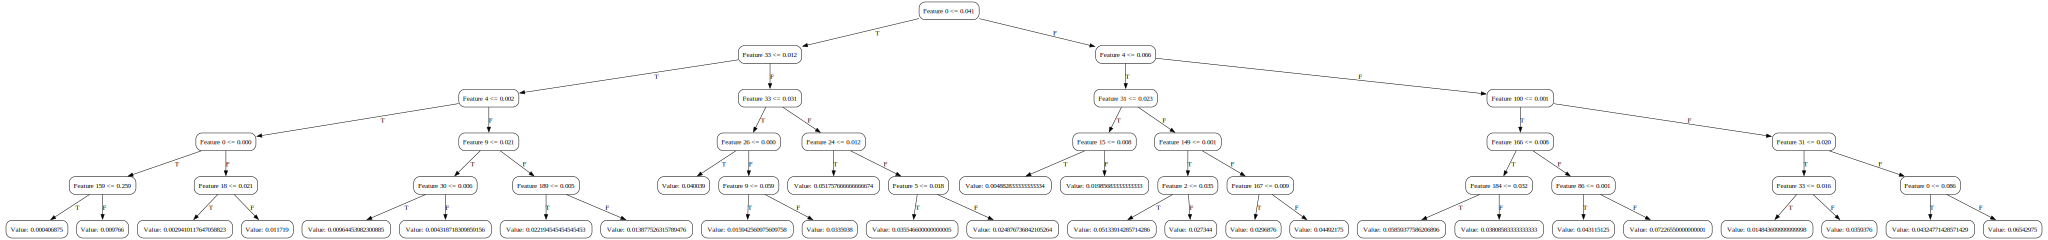

In [10]:
import graphviz
dot = graphviz.Digraph(node_attr={'shape': 'box', 'style': 'rounded'})
count = [0]

def get_graph(node):
    uid = str(count[0])
    count[0] += 1

    # Leaf Node
    if node.value is not None:
        dot.node(uid, f'Value: {node.value}')
        
    # Decision Node
    else:
        dot.node(uid, f'Feature {node.feature_idx} <= {node.threshold:.3f}')
        if node.left: dot.edge(uid, get_graph(node.left), "T")
        if node.right: dot.edge(uid, get_graph(node.right), "F")
    return uid
        
get_graph(rt.root)
dot

### Tree Pruning
The process described above may produce good predictions on the training
set, but is likely to overfit the data, leading to poor test set performance.
This is because the resulting tree might be too complex. A smaller tree 
with fewer splits (that is, fewer regions R1, . . . , RJ ) might lead to lower
variance and better interpretation at the cost of a little bias.

Pruning would be of course done wrt a validation dataset.

Pruning is nothing but regularization using terminal node count.

For each value of α there corresponds a subtree $T \in  T_0$ such that 
$$ Cost\ Complexity = \sum_{m=1}^{|T|} \sum_{i:x_i \in R_m} (y_i - \hat{y}R_m)^2 + \alpha|T|$$
Basically for some tree $T$ that is a subset of the main large tree with $|T|$ leaf nodes, we are trying to get the optimal $T$ for some hyperparameter $\alpha$ that minimizes the loss function + alpha * leaf node count.

This would prevent a new node specifically when the regularization part of loss function $\alpha|T|$ increases more than the decrease in loss of adding that specific node.

### Algo:
1. Find $\alpha_{eff}$ for every internal node in the tree.
2. Identify the node with least $\alpha_{eff}$, this division provides least improvement per added node count.
3. Collapse the node.
4. Repeat the process for the new, slightly smaller tree. Continue till you are left with only the root node.
5. Final tree is chosen using cross validation.
* This final tree would have higher training loss, less variance, but greater generalization. 

"Weakest Link" is the internal node that, if collapsed into a single leaf, results in the smalled increase in error per leaf removed. For every internal node t ,we calculate an effective alpha ($\alpha_{eff}$):

Finding the breaking point where the alpha term over power the loss in the cost function.
$$ R(With\ t\ as\ Leaf\ Node) - R(With\ t\ as\ Decision\ Node) = \alpha * (LNs\ with\ t\ as\ DN - LNs\ with\ t\ as\ LN)$$
$$ \alpha_{eff}(t) = \frac{R(t) - R(T_t) }{|T_t| - 1} $$
Where,
* $R(t)$: The error if node t is treated as leaf.
* $R(T_t)$: The total error of the entire subtree starting at node t.
* $|T_t| - 1$: The number of leaves we "lose" by collapsing the subtree into node t.


In [137]:
rt = RegressionTree(min_samples_split=7, max_depth=float('inf'))
s = time.time()
rt.fit(X_train, y_train)
e = time.time()

y_pred = rt.predict(X_valid)
rmse = np.sqrt(np.mean(np.square(y_valid- y_pred)))
(f"RMSE: {rmse}"), e - s

('RMSE: 0.011318259505991472', 3.3363661766052246)

In [138]:
# Trying to find the depth of this tree:
depth = 0
node = rt.root
while node is not None:
    depth += 1
    node = node.right
depth

6

In [139]:
import copy

In [140]:
# Finding number of roots:
def count_node(node, count):
    if node.feature_idx is None:
        count[0]+=1
        return
    count_node(node.left, count)
    count_node(node.right, count)

# Predciting Using that single node
def predict(X, node):
    predictions = [predict_value(row, node) for row in X]
    return predictions

def predict_value(x, node):
    # Leaf Node: Base case
    if node.value is not None:
        return node.value
    # Decision Node
    feature_value = x[node.feature_idx] 
    if feature_value <= node.threshold:
        return predict_value(x, node.left)
    else:
        return predict_value(x, node.right)

def rss(y, y_hat):
    return np.sum(np.square(y-y_hat))

# making a function that updates the tree with each decision node having one more attribute for alphaeff:
def calc_alpha_eff(X, y, node):
    if node.value is not None:
        return
        
    # For finding the alpha_eff we need:
    # 1) |T|
    leaf_count = [0]
    count_node(node, leaf_count)

    # 2) Prediction like DN
    y_predicted = predict(X, node)
    
    # 3) Predicted like TN
    avg_val = np.mean(y)
    node.avg_val = avg_val

    # Calculating Alpha:
    alpha_eff = (rss(avg_val, y) - rss(y_predicted, y)) / (leaf_count[0] - 1)
    node.alpha = alpha_eff

    # Propagation:
    mask = X[:, node.feature_idx] <= node.threshold
    calc_alpha_eff(X[mask], y[mask], node.left)
    calc_alpha_eff(X[~mask], y[~mask], node.right)


In [141]:
calc_alpha_eff(X_train, y_train, rt.root)

In [142]:
rt.root.left.alpha

np.float64(0.0003568652747272527)

In [143]:
# Building sub trees while dropping the least alpha nodes, till left with the root
# Finally finding RSS over the validation dataset for all vlaues of alpha using the corresponding trees

trees = []
alphas = []

def min_alpha(root, node):
    if root is None or root.feature_idx is None:
        return
    if node[0].alpha > root.alpha:
        node[0] = root
    min_alpha(root.right, node)
    min_alpha(root.left, node)

def build_sub_trees(rt, X, y):
    if rt.root.feature_idx is None:
        return

    # Making copy of the tree
    rt = copy.deepcopy(rt)
    
    # Getting the internal node with miniumum alpha
    node = [rt.root]
    min_alpha(rt.root, node)

    # Removing the node in the sub tree
    node = node[0]
    node.feature_idx = None
    node.threshold = None
    node.info_gain = None
    node.left = None
    node.right = None

    # Making the DN as a LN
    node.value = node.avg_val

    # Adding this to our arsenal
    trees.append(rt)
    alphas.append(node.alpha)

    # Doing this again and again till root is left
    build_sub_trees(rt, X, y)
    

In [145]:
build_sub_trees(rt, X_train, y_train)

In [146]:
len(trees), len(alphas)

(145, 145)

In [156]:
def loss(prediction, y):
    return np.sqrt(np.mean(np.square(prediction - y)))

In [157]:
valid_loss = []
test_loss = []
for tree in trees:
    prediction = tree.predict(X_valid)
    valid_loss.append(loss(prediction, y_valid))
    prediction = tree.predict(X_train)
    test_loss.append(loss(prediction, y_train))

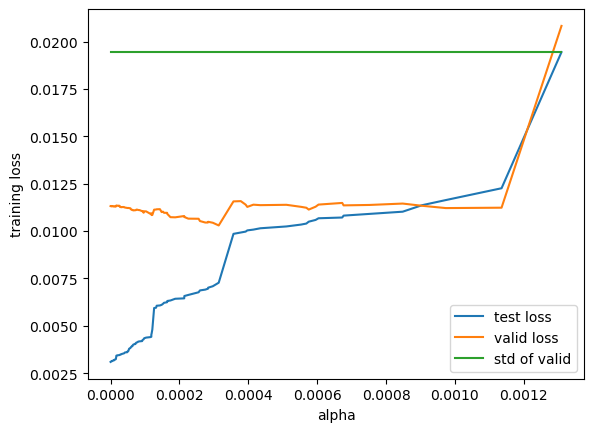

In [158]:
plt.plot(alphas, test_loss, label='test loss')
plt.plot(alphas, valid_loss, label='valid loss')
plt.plot(alphas, np.std(y_train) * np.ones(len(alphas)), label='std of valid')
plt.xlabel('alpha')
plt.ylabel('training loss')
plt.legend()
plt.show()

In [159]:
test_loss

[np.float64(0.0030931874305263436),
 np.float64(0.0030931874305263436),
 np.float64(0.0030931874305263436),
 np.float64(0.0030931874305263436),
 np.float64(0.0030931874305263436),
 np.float64(0.0030931874305263436),
 np.float64(0.0030931874305263436),
 np.float64(0.0030939580990116803),
 np.float64(0.003094713470040415),
 np.float64(0.0030954539946745113),
 np.float64(0.0030970101312502813),
 np.float64(0.003103554527126518),
 np.float64(0.0031042706338015166),
 np.float64(0.003106992469424446),
 np.float64(0.0031078042819746897),
 np.float64(0.0031115553910764575),
 np.float64(0.003112349009563576),
 np.float64(0.003118034812217477),
 np.float64(0.0031197994981059115),
 np.float64(0.003120460998025785),
 np.float64(0.003121122357745409),
 np.float64(0.0031245298521788705),
 np.float64(0.0031420568990293022),
 np.float64(0.0031429508635359336),
 np.float64(0.0031457704102640753),
 np.float64(0.003150271488389668),
 np.float64(0.0031513632505511787),
 np.float64(0.003152672866086942),
 

In [155]:
np.std(y_train)

np.float64(0.019447903449992223)